(lecture10:homework)=
# Homework 10

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Timothy
+ **Last Name:** Lee
+ **Email:** lee5695@purdue.edu

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st

/tmp/ipykernel_7515/122018214.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


(lecture10:homework:problem1)=
## Problem 1 - An alternative way to construct the generalized uniform distribution $U([a,b])$

Let $Z$ be a standard uniform random variable:

$$
Z\sim U([0,1]).
$$

Define the random variable:

$$
X = a + (b-a) Z.
$$

+ Show that:

$$
X\sim U([a,b]).
$$

Hint: Prove that the CDF of $X$ is $F_X(x) = p(X\le x) = \frac{x-a}{b-a}$. This is one line.

**Answer:**

$F_X(x) = p(X\le x)$<br>
$\hspace{1.5cm}=p(a+(b-a)Z\le x)$<br>
$\hspace{1.5cm}=p((b-a)Z\le x-a)$<br>
$\hspace{1.5cm}=p(Z\le \frac{x-a}{b-a})$<br>

Z is a standard uniform random variable, so $F_Z(z)=p(Z\le z)=z$<br>

Thus, $F_X(x) = \frac{x-a}{b-a}$<br>

This is the CDF of a uniform distribution because:
*   for $x<a$ the CDF = 0
*   for $a<x<b$ the CDF = $\frac{x-a}{b-a}$
*   for $x>b$ the CDF = 1

Therefore, $X\sim U([a,b])$

+ The function `numpy.random.rand` gives you uniform random samples in $[0, 1]$.
Take 1,000 such samples and transform them to uniform samples in $[-1, 5]$.
Hint: Fill in the missing code below.

In [86]:
a = -1
b = 5
z = np.random.rand(1000)
x = a + (b - a) * z

Test if you are getting the right answer by doing the histogram of your samples (it should be almost flat between -1 and 5):

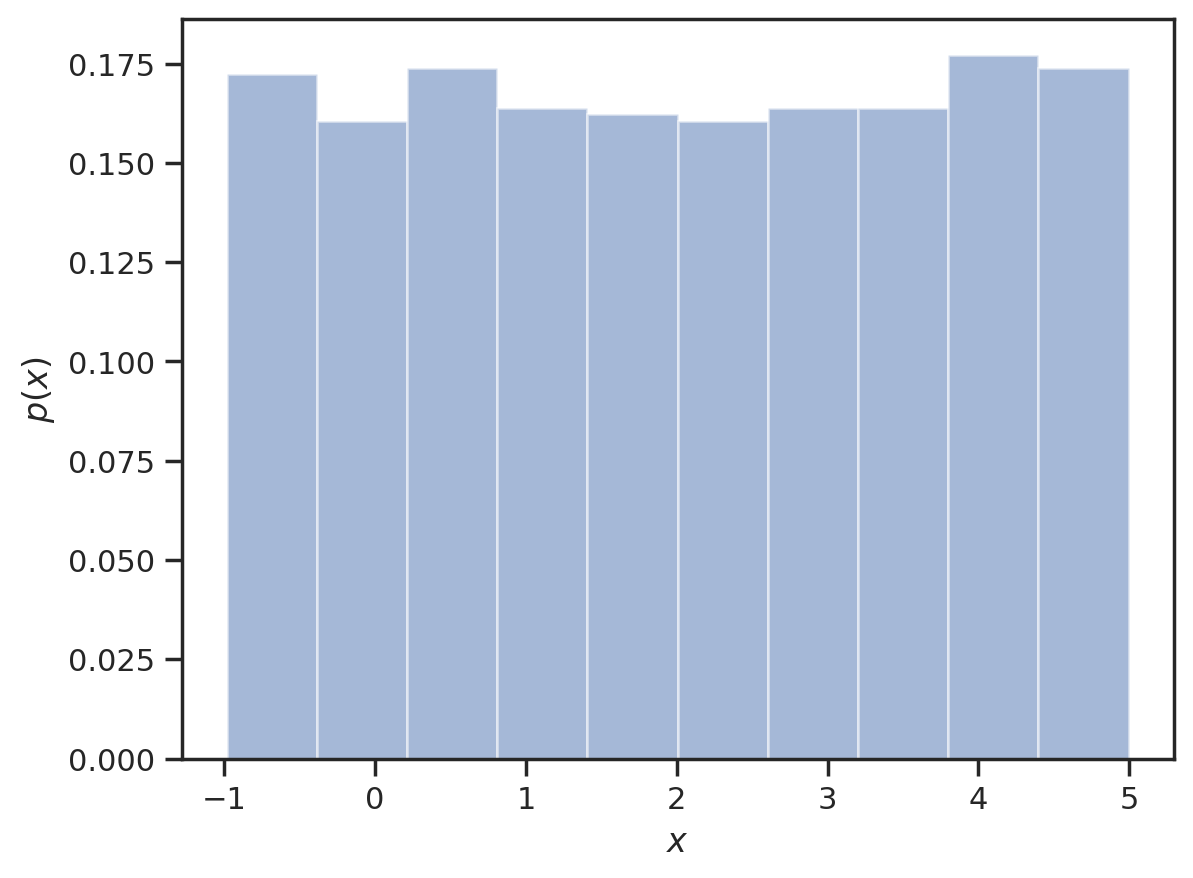

In [87]:
fig, ax = plt.subplots()
ax.hist(x, density=True, alpha=0.5)
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$');

(lecture10:homework:problem2)=
# Problem 2 - The Exponential distribution

The Exponential distribution models the probability distribution of the time between events which occur [continuously and independently at a constant rate](https://en.wikipedia.org/wiki/Exponential_distribution).
Examples of such a situation are:
+ The time between phone calls in a help center.
+ The time between the arrival of cars at a toll station.
+ The time between the arrival of customers.
+ The time between two earthquakes.
+ The time between two micrometeoroid impacts on an Moon research base.
+ The time between faults in a mechanical system. However, this is a gross approximation because the rate of faults in a mechanical system increases with time, it is not constant.

We write:

$$
T \sim \text{Exp}(\lambda),
$$

and we read:

> $T$ follows an Exponential distribution with rate parameter $\lambda$.

The rate parameter $\lambda$ is positive and has units of inverse time.
You can think of $\lambda$ as the number of events per unit of time.

The CDF of the Exponential is:

$$
F(t) = \begin{cases}
0,& t < 0,\\
1 - e^{-\lambda t},& t \ge 0.
\end{cases}
$$

+ Prove mathematically that the PDF of the random variable $T$ is:

$$
p(t) = \lambda e^{-\lambda t}.
$$

Hint: Use one of the properties of the PDF.

**Answer:**

$p(t) = \frac{d}{dt}F(t)$<br>
$\hspace{1 cm} = \frac{d}{dt}(1-e^{-\lambda t})$<br>
$\hspace{1 cm}= (-\lambda)(-e^{-\lambda t})$<br>
$\hspace{1 cm}= \lambda e^{-\lambda t}$

+ [Micrometeoroids](https://en.wikipedia.org/wiki/Micrometeoroid) make space exploration very challenging.
Even though the mass of these projectiles is very small (less than 1 gram), they move with a very high-velocity
(of the order of 10 km per second) and thus they are will be gradually degrading the protective layers of deep space habitats.
For a Moon base with an area of 1000 squared meters, the rate of micrometeoroid impacts is about:

$$
\lambda = 3\times 10^{-6}\;\text{s}^{-1}.
$$

Read the [scipy.stats.expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html) documentation and make an Exponential random variable $T$ with this rate:

In [51]:
# You cannot use lambda because it is a reserved word.
# Call the rate lam instead:
lam = 3e-6 # in inverse seconds
T = st.expon(scale = 1 / lam)

+ Take 1000 samples from the random variable you just constructed and draw their histogram.


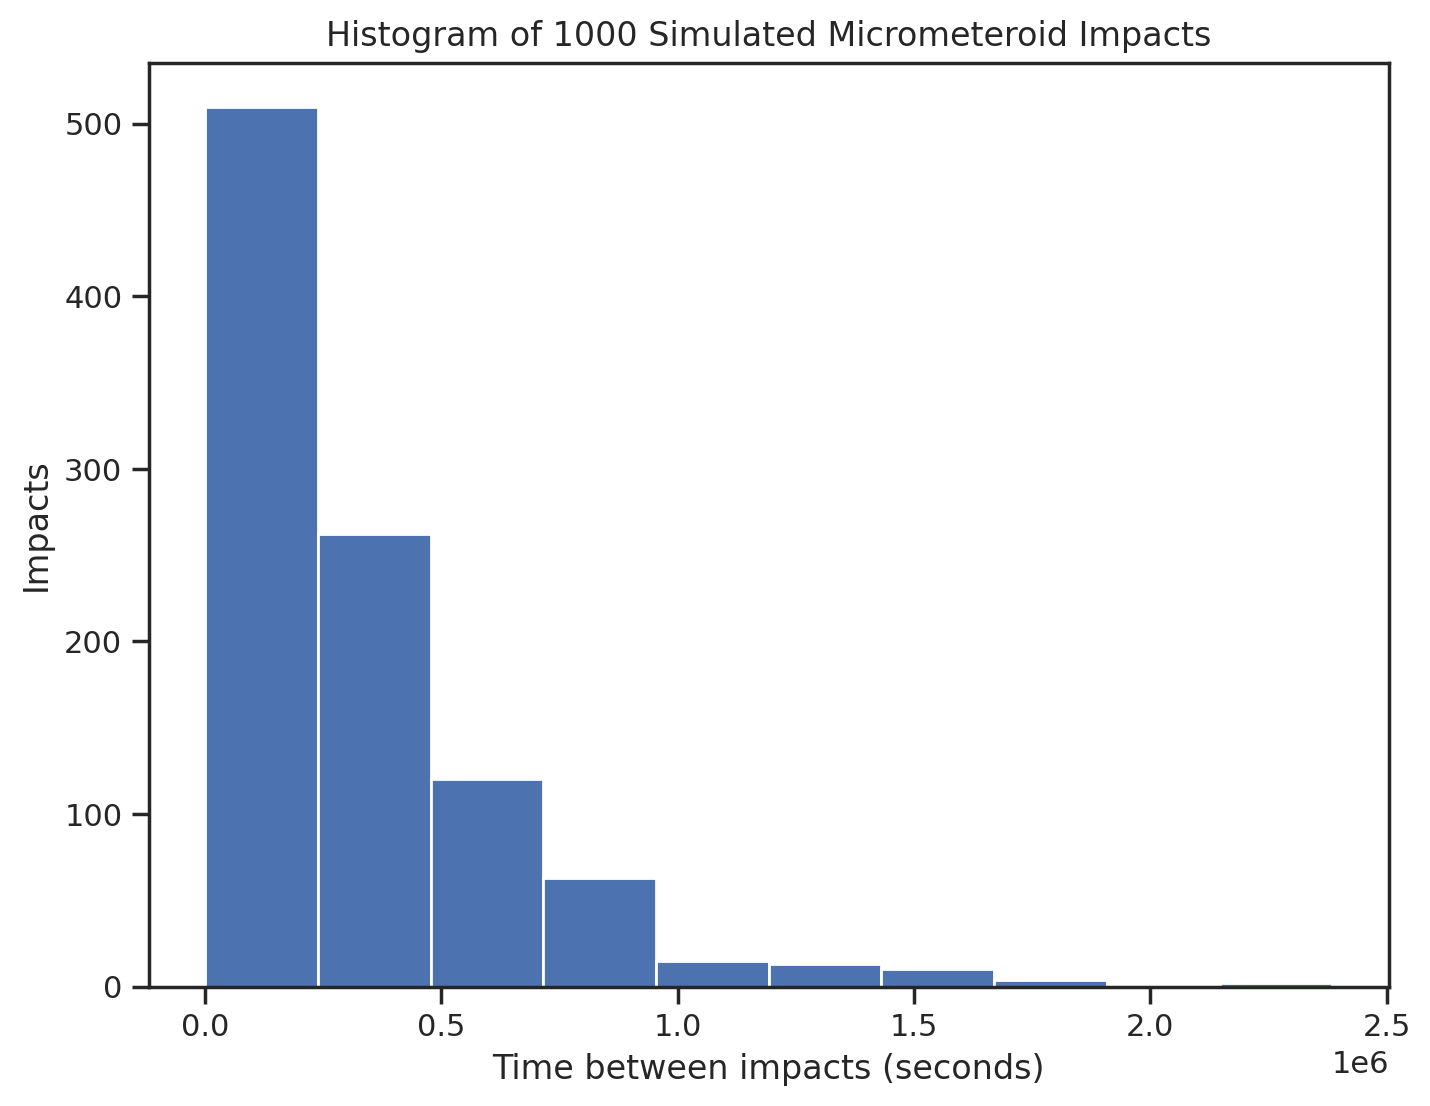

In [97]:
samples = T.rvs(size=1000)

plt.figure(figsize=(8,6))
plt.hist(samples)
plt.xlabel('Time between impacts (seconds)')
plt.ylabel('Impacts')
plt.title('Histogram of 1000 Simulated Micrometeroid Impacts')
plt.show()

+ Plot the CDF of $T$:

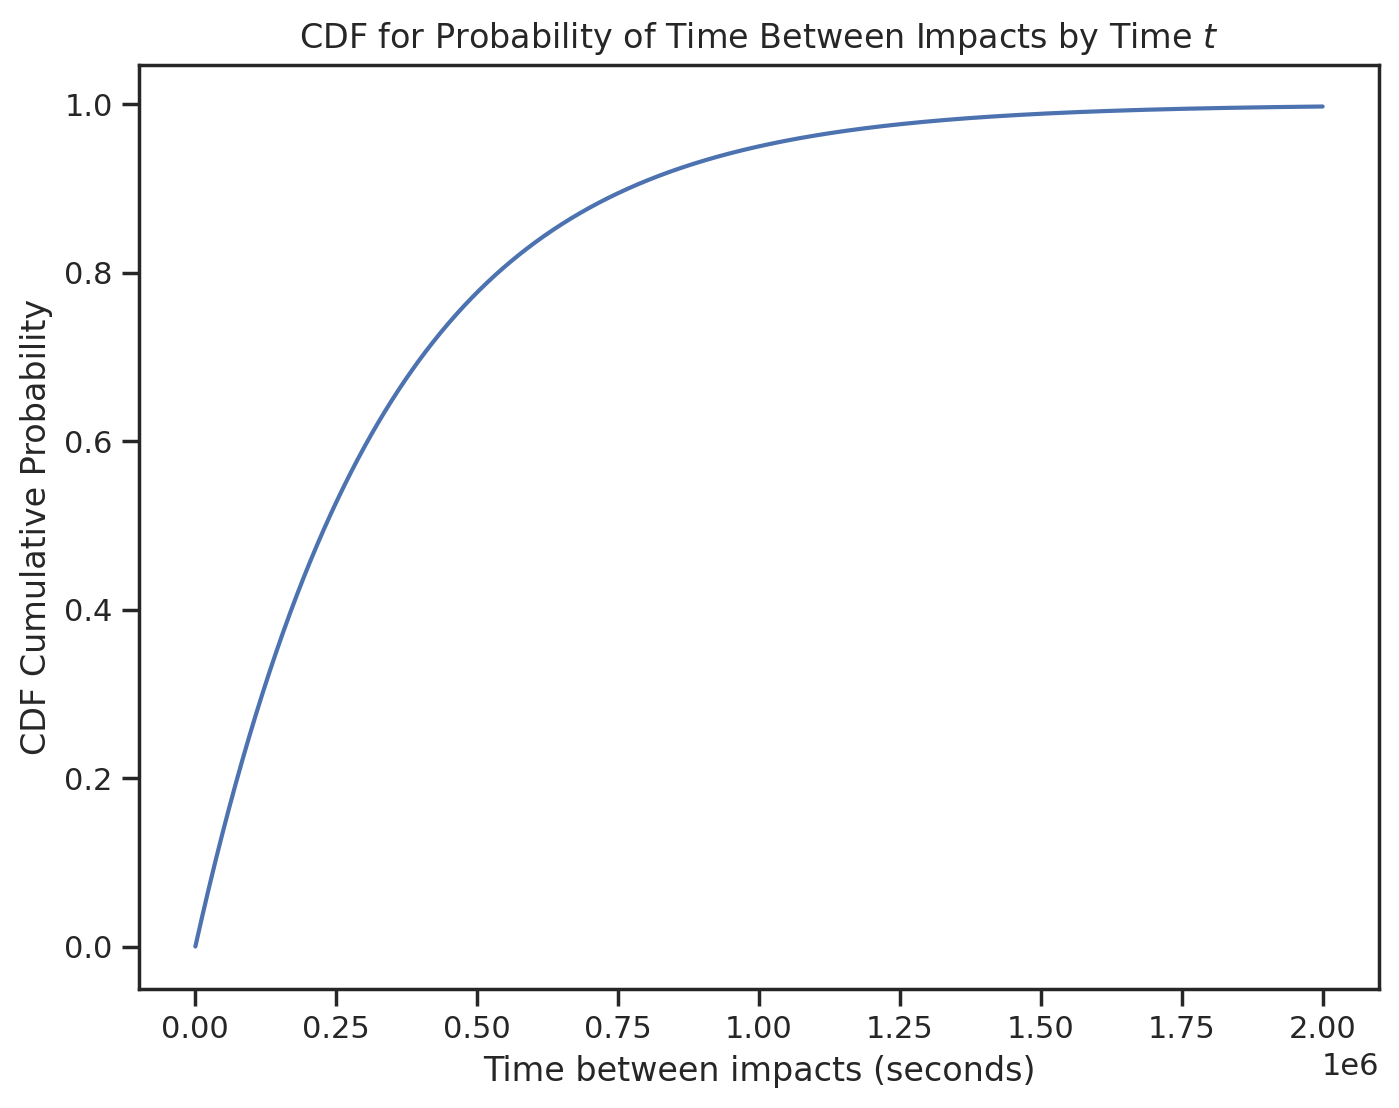

In [98]:
xs = np.linspace(0, 2e6, 1000)

plt.figure(figsize=(8,6))
plt.plot(xs, T.cdf(xs))
plt.xlabel('Time between impacts (seconds)')
plt.ylabel('CDF Cumulative Probability')
plt.title('CDF for Probability of Time Between Impacts by Time $t$')
plt.show()

+ Find the probability that we have a micrometeoroid impact within a day.
Hint: Remember that the units of $T$ are seconds.

In [72]:
prob = T.cdf(24*60*60)
print(prob)

# The probability that we have a micrometeroid impact within a day is 0.22833132612547385

0.22833132612547385


+ Plot the PDF of T.

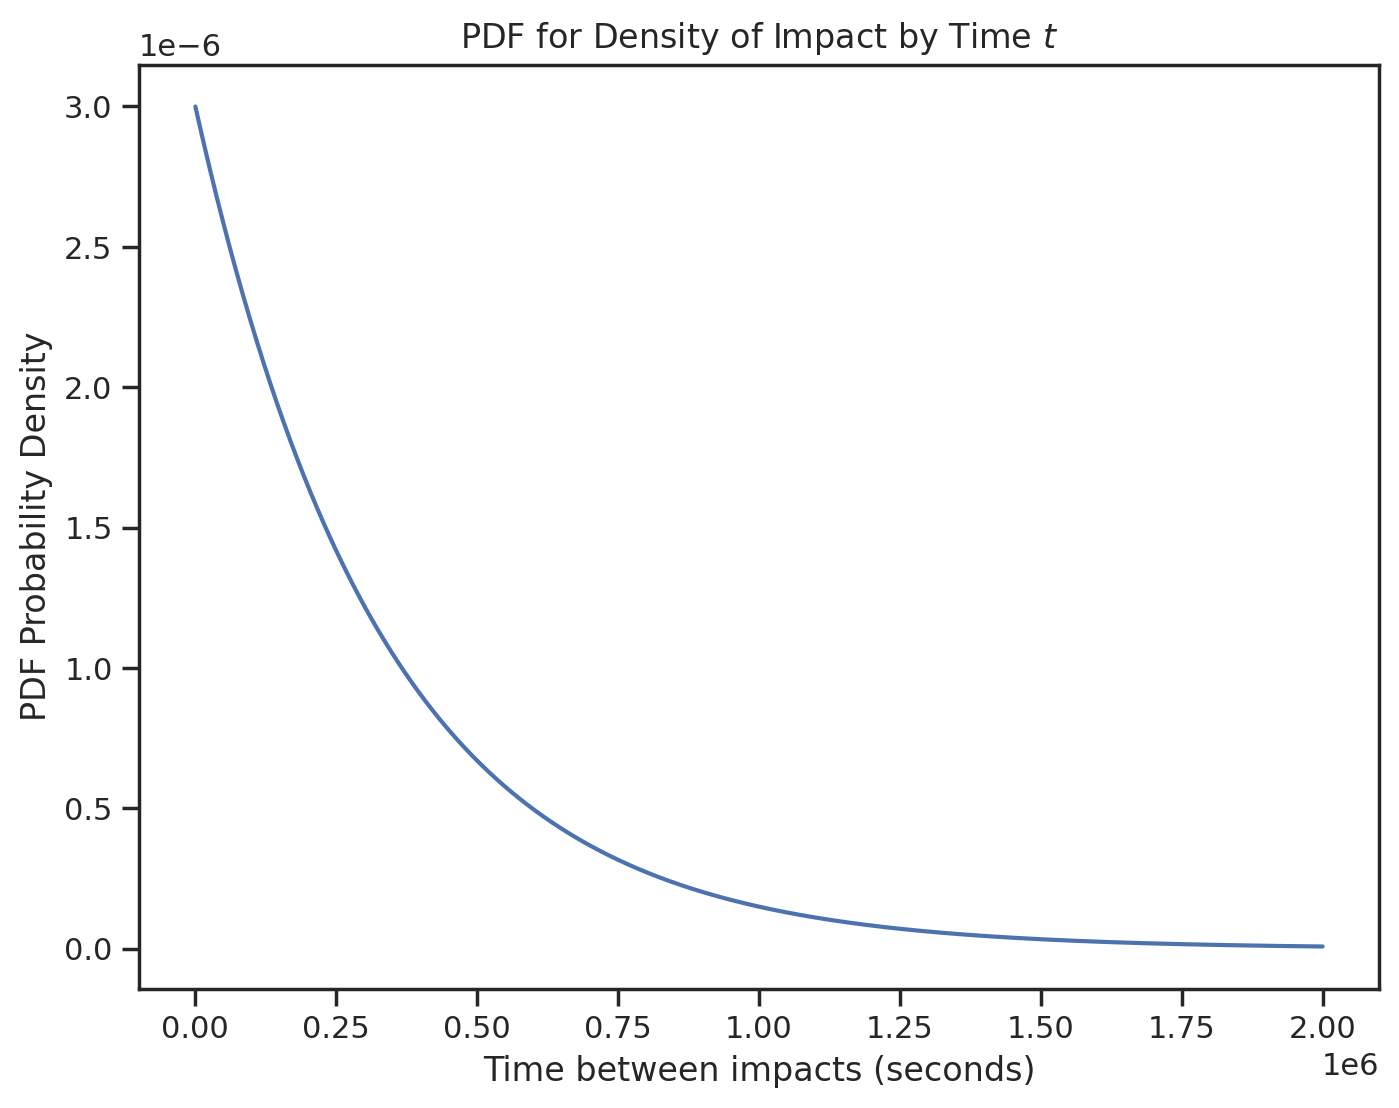

In [99]:
plt.figure(figsize=(8,6))
plt.plot(xs, T.pdf(xs))
plt.xlabel('Time between impacts (seconds)')
plt.ylabel('PDF Probability Density')
plt.title('PDF for Density of Impact by Time $t$')
plt.show()

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_10.ipynb'